# Monitorização da pressão assistencial nas urgências hospitalares do SNS

## Projeto 1 — Análise exploratória e diagnóstico operacional

Este notebook faz parte de um projeto de portefólio em Health Data Science focado em serviços de urgência, tempos de espera, fluxo de doentes e congestionamento hospitalar.

O objetivo deste primeiro projeto é caracterizar e monitorizar a pressão assistencial nas urgências hospitalares do SNS em Portugal, usando dados públicos agregados.

## Pergunta principal

Como evolui a pressão assistencial nos serviços de urgência hospitalar do SNS em Portugal e que indicadores públicos permitem monitorizar padrões de congestionamento ao longo do tempo e entre instituições?

## Objetivos

### Objetivo geral

Caracterizar e monitorizar a pressão assistencial nas urgências hospitalares do SNS em Portugal, usando dados públicos sobre volume de atendimentos, tempos médios de espera, triagem e internamento.

### Objetivos específicos

- Analisar a evolução temporal do volume de atendimentos urgentes.
- Analisar a evolução do tempo médio entre triagem e primeira observação médica.
- Explorar a relação entre volume, tempo de espera, triagem e taxa de internamento.
- Comparar padrões entre instituições hospitalares e/ou regiões.
- Identificar indicadores úteis para monitorização de congestionamento.
- Construir um indicador exploratório de pressão assistencial.

## Estrutura prevista do notebook

1. Importação de bibliotecas e configuração inicial
2. Compreensão inicial do dataset principal
3. Qualidade dos dados
4. Preparação dos dados
5. Validação da tabela analítica
6. Análise exploratória inicial
7. Síntese dos principais achados
8. Limitações
9. Próximos passos

## 1. Importação de bibliotecas e configuração inicial

Nesta secção serão carregadas as bibliotecas necessárias para a análise exploratória e será definida a localização dos ficheiros de dados.

O objetivo inicial é apenas confirmar que o dataset principal foi guardado corretamente e que pode ser lido no ambiente de trabalho.

In [42]:
from pathlib import Path

import pandas as pd

# Biblioteca usada para criar gráficos
import matplotlib.pyplot as plt


In [43]:
DATA_RAW = Path("../data/raw")
main_dataset_path = DATA_RAW / "monitorizacao_sazonal_csh_raw.csv"

main_dataset_path.exists()

True

In [44]:
df_main = pd.read_csv(main_dataset_path, sep=";")

df_main.head()

,Período,Região/ARS,Indicador,Valor,Unidade,ID
0,2017-02-13,ARS Lisboa e Vale do Tejo,Tempo médio de espera entre a triagem e a prim...,47.867240,minuto,2017-02-13/ARS Lisboa e Vale do Tejo/Tempo méd...
1,2017-02-14,Portugal Continental,Tempo médio de espera entre a triagem e a prim...,46.503490,minuto,2017-02-14/Portugal Continental/Tempo médio de...
2,2017-02-14,ARS Alentejo,Número estimado de episódios de urgência,1048.000000,episódio urgência,2017-02-14/ARS Alentejo/Número estimado de epi...
3,2017-02-14,ARS Alentejo,Taxa diária de atendimentos urgentes com prior...,39.185390,epis. urg./100.000 resid.,2017-02-14/ARS Alentejo/Taxa diária de episódi...
4,2017-02-14,ARS Norte,Taxa diária de atendimentos urgentes com inter...,8.190686,%,2017-02-14/ARS Norte/Taxa diária de episódios ...


### Nota sobre leitura do ficheiro

O ficheiro CSV foi exportado do Portal da Transparência do SNS com separador `;`.

Por isso, a leitura com `pandas` deve usar o argumento `sep=";"`.

## 2. Compreensão inicial do dataset principal

Nesta secção é feita uma primeira inspeção ao dataset principal, incluindo dimensão da tabela, nomes das colunas, tipos de dados e indicadores disponíveis.

O objetivo é perceber a estrutura dos dados antes de qualquer transformação.

In [45]:
df_main.shape

(82154, 6)

In [46]:
df_main.columns.tolist()

['Período', 'Região/ARS', 'Indicador', 'Valor', 'Unidade', 'ID']

In [47]:
df_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 82154 entries, 0 to 82153
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Período     82154 non-null  str    
 1   Região/ARS  82154 non-null  str    
 2   Indicador   82154 non-null  str    
 3   Valor       82154 non-null  float64
 4   Unidade     82154 non-null  str    
 5   ID          82154 non-null  str    
dtypes: float64(1), str(5)
memory usage: 3.8 MB


In [48]:
df_main.head(10)

,Período,Região/ARS,Indicador,Valor,Unidade,ID
0,2017-02-13,ARS Lisboa e Vale do Tejo,Tempo médio de espera entre a triagem e a prim...,47.867240,minuto,2017-02-13/ARS Lisboa e Vale do Tejo/Tempo méd...
1,2017-02-14,Portugal Continental,Tempo médio de espera entre a triagem e a prim...,46.503490,minuto,2017-02-14/Portugal Continental/Tempo médio de...
2,2017-02-14,ARS Alentejo,Número estimado de episódios de urgência,1048.000000,episódio urgência,2017-02-14/ARS Alentejo/Número estimado de epi...
3,2017-02-14,ARS Alentejo,Taxa diária de atendimentos urgentes com prior...,39.185390,epis. urg./100.000 resid.,2017-02-14/ARS Alentejo/Taxa diária de episódi...
4,2017-02-14,ARS Norte,Taxa diária de atendimentos urgentes com inter...,8.190686,%,2017-02-14/ARS Norte/Taxa diária de episódios ...
5,2017-02-14,ARS Norte,Tempo médio de espera entre a triagem e a prim...,41.273070,minuto,2017-02-14/ARS Norte/Tempo médio de espera ent...
6,2017-02-15,Portugal Continental,Taxa diária de atendimentos urgentes com prior...,38.654630,epis. urg./100.000 resid.,2017-02-15/Portugal Continental/Taxa diária de...
7,2017-02-15,ARS Lisboa e Vale do Tejo,Taxa diária de atendimentos urgentes com inter...,8.884231,%,2017-02-15/ARS Lisboa e Vale do Tejo/Taxa diár...
8,2017-02-15,ARS Lisboa e Vale do Tejo,Tempo médio de espera entre a triagem e a prim...,57.487580,minuto,2017-02-15/ARS Lisboa e Vale do Tejo/Tempo méd...
9,2017-02-15,ARS Algarve,Taxa diária de atendimentos urgentes com inter...,6.781915,%,2017-02-15/ARS Algarve/Taxa diária de episódio...


In [49]:
df_main["Indicador"].value_counts()

Indicador
Número estimado de episódios de urgência                                                              20838
Taxa diária de atendimentos urgentes com prioridade verde ou azul                                     20541
Taxa diária de atendimentos urgentes com internamento                                                 20540
Tempo médio de espera entre a triagem e a primeira observação médica (rede de urgência hospitalar)    20235
Name: count, dtype: int64

In [50]:
print(f"Período mínimo: {df_main['Período'].min()}")
print(f"Período máximo: {df_main['Período'].max()}")
print(f"Regiões: {df_main['Região/ARS'].value_counts()}")

Período mínimo: 2016-11-01
Período máximo: 2026-05-09
Regiões: Região/ARS
ARS Lisboa e Vale do Tejo    13892
Portugal Continental         13892
ARS Alentejo                 13892
ARS Norte                    13892
ARS Centro                   13892
ARS Algarve                  12694
Name: count, dtype: int64


## 3. Qualidade dos dados

Nesta secção são avaliadas a cobertura dos dados, a existência de registos em falta por região e indicador, e possíveis limitações que possam afetar a interpretação dos resultados.

Esta etapa é importante porque o dataset é agregado e pode apresentar diferenças de cobertura entre regiões, indicadores e períodos temporais.

Nesta primeira contagem observa-se que a ARS Algarve apresenta menor número de registos do que as restantes agregações territoriais. Esta diferença será investigada nas etapas seguintes de qualidade dos dados.

In [51]:
# Período min e máximo por região/ars
df_main.groupby('Região/ARS')['Período'].agg(['min', 'max'])


,min,max
Região/ARS,,
ARS Alentejo,2016-11-01,2026-05-09
ARS Algarve,2016-11-01,2026-05-09
ARS Centro,2016-11-01,2026-05-09
ARS Lisboa e Vale do Tejo,2016-11-01,2026-05-09
ARS Norte,2016-11-01,2026-05-09
Portugal Continental,2016-11-01,2026-05-09


O período obtido é igual em todas as ARS

In [52]:
tabela_regiao_indicador = pd.crosstab(df_main['Região/ARS'], df_main['Indicador'])
tabela_regiao_indicador

Indicador,Número estimado de episódios de urgência,Taxa diária de atendimentos urgentes com internamento,Taxa diária de atendimentos urgentes com prioridade verde ou azul,Tempo médio de espera entre a triagem e a primeira observação médica (rede de urgência hospitalar)
Região/ARS,,,,
ARS Alentejo,3473,3473,3473,3473
ARS Algarve,3473,3175,3176,2870
ARS Centro,3473,3473,3473,3473
ARS Lisboa e Vale do Tejo,3473,3473,3473,3473
ARS Norte,3473,3473,3473,3473
Portugal Continental,3473,3473,3473,3473


### Nota sobre cobertura dos dados por região e indicador

A análise do número de registos por Região/ARS e por Indicador mostra que a ARS Algarve apresenta menor cobertura em alguns indicadores, especialmente no indicador "Tempo médio de espera entre a triagem e a primeira observação médica".

Esta diferença não aparece como valores nulos nas colunas, mas sim como menor número de registos disponíveis para essa combinação de região e indicador.

Por este motivo, comparações envolvendo a ARS Algarve, sobretudo no indicador de tempo médio de espera, devem ser interpretadas com cautela.

In [53]:
df_quality = df_main.copy()

# Converter a coluna "Período" para o tipo datetime
df_quality["Período"] = pd.to_datetime(df_quality["Período"])

In [54]:
indicador_espera = "Tempo médio de espera"

df_espera = df_quality[df_quality["Indicador"].str.contains(indicador_espera, case=False, na=False)].copy()

df_espera["Indicador"].unique()

<StringArray>
['Tempo médio de espera entre a triagem e a primeira observação médica (rede de urgência hospitalar)']
Length: 1, dtype: str

In [55]:
df_espera.groupby("Região/ARS")["Período"].agg(['min', 'max', "count"])

,min,max,count
Região/ARS,,,
ARS Alentejo,2016-11-01,2026-05-09,3473
ARS Algarve,2016-11-01,2026-05-09,2870
ARS Centro,2016-11-01,2026-05-09,3473
ARS Lisboa e Vale do Tejo,2016-11-01,2026-05-09,3473
ARS Norte,2016-11-01,2026-05-09,3473
Portugal Continental,2016-11-01,2026-05-09,3473


In [56]:
datas_todas_regiões = set(df_espera["Período"].unique())

datas_alg = set(df_espera.loc[df_espera["Região/ARS"] == "ARS Algarve", "Período"].unique())

datas_em_falta_alg = sorted(datas_todas_regiões - datas_alg)

len(datas_em_falta_alg)

603

In [57]:
datas_em_falta_alg[:10], datas_em_falta_alg[-10:]

([Timestamp('2016-12-05 00:00:00'),
  Timestamp('2016-12-06 00:00:00'),
  Timestamp('2016-12-07 00:00:00'),
  Timestamp('2016-12-08 00:00:00'),
  Timestamp('2017-02-04 00:00:00'),
  Timestamp('2017-02-05 00:00:00'),
  Timestamp('2017-02-06 00:00:00'),
  Timestamp('2017-02-07 00:00:00'),
  Timestamp('2017-02-08 00:00:00'),
  Timestamp('2017-02-09 00:00:00')],
 [Timestamp('2026-04-22 00:00:00'),
  Timestamp('2026-04-23 00:00:00'),
  Timestamp('2026-04-24 00:00:00'),
  Timestamp('2026-04-25 00:00:00'),
  Timestamp('2026-04-26 00:00:00'),
  Timestamp('2026-04-27 00:00:00'),
  Timestamp('2026-04-28 00:00:00'),
  Timestamp('2026-05-03 00:00:00'),
  Timestamp('2026-05-05 00:00:00'),
  Timestamp('2026-05-06 00:00:00')])

In [58]:
df_faltas_algarve = pd.DataFrame({
    "data_em_falta": datas_em_falta_alg
})

df_faltas_algarve["ano"] = df_faltas_algarve["data_em_falta"].dt.year
df_faltas_algarve["mes"] = df_faltas_algarve["data_em_falta"].dt.month

df_faltas_algarve.groupby("ano").size()

ano
2016      4
2017    153
2018      8
2019    147
2023      4
2024    100
2025     66
2026    121
dtype: int64

In [59]:
df_faltas_algarve.groupby(["ano", "mes"]).size()

ano   mes
2016  12      4
2017  2      19
      3      29
      4      19
      5      10
      6      21
      7      26
      8      11
      10      1
      11      9
      12      8
2018  1       1
      2       1
      3       2
      10      1
      11      3
2019  5       2
      6       3
      7      26
      8      30
      9      25
      10     28
      11     24
      12      9
2023  1       3
      3       1
2024  4       1
      6      25
      7      30
      8      16
      9       5
      10      3
      11     10
      12     10
2025  1       2
      2       3
      3       1
      4       5
      5       6
      6       9
      7       1
      8       2
      9       3
      10      3
      11      7
      12     24
2026  1      31
      2      28
      3      31
      4      28
      5       3
dtype: int64

### Cobertura temporal do indicador de tempo médio de espera

Na análise de qualidade dos dados, verificou-se que a ARS Algarve apresenta menor cobertura no indicador "Tempo médio de espera entre a triagem e a primeira observação médica".

Foram identificadas 603 datas em falta para a ARS Algarve neste indicador, quando comparada com o conjunto de datas disponíveis nas restantes regiões. As falhas parecem estar espalhadas ao longo da série temporal, com maior concentração em alguns anos, nomeadamente 2017, 2019, 2024 e 2026.

Esta limitação será considerada nas análises regionais, sobretudo em comparações de tempo médio de espera e tendências temporais.

## 4. Preparação dos dados

### 4.1 Criação do dataframe preparado

In [60]:
df_prepared = df_main.copy()

# Passar a coluna "Período" para formato datetime
df_prepared["Período"] = pd.to_datetime(df_prepared["Período"])

# Renomar colunas para facilitar o acesso
df_prepared.rename(columns={
    "Período": "periodo",
    "Região/ARS": "regiao_ars",
    "Indicador": "indicador",
    "Valor": "valor",
    "Unidade": "unidade",
    "ID": "id"
}, inplace=True)

# Criar variáveis temporais
df_prepared["ano"] = df_prepared["periodo"].dt.year
df_prepared["mes"] = df_prepared["periodo"].dt.month
df_prepared["ano_mes"] = df_prepared["periodo"].dt.to_period("M")


# Função para classificar o estado de um ano
def classificar_estado_ano(ano):
    if ano in [2016, 2026]:
        return "parcial"
    elif ano == 2025:
        return "completo_com_falhas"
    else:
        return "completo"

# Identificar anos completos e ano parcial
df_prepared["estado_ano"] = df_prepared["ano"].apply(classificar_estado_ano)


df_prepared.head()


,periodo,regiao_ars,indicador,valor,unidade,id,ano,mes,ano_mes,estado_ano
0,2017-02-13,ARS Lisboa e Vale do Tejo,Tempo médio de espera entre a triagem e a prim...,47.867240,minuto,2017-02-13/ARS Lisboa e Vale do Tejo/Tempo méd...,2017,2,2017-02,completo
1,2017-02-14,Portugal Continental,Tempo médio de espera entre a triagem e a prim...,46.503490,minuto,2017-02-14/Portugal Continental/Tempo médio de...,2017,2,2017-02,completo
2,2017-02-14,ARS Alentejo,Número estimado de episódios de urgência,1048.000000,episódio urgência,2017-02-14/ARS Alentejo/Número estimado de epi...,2017,2,2017-02,completo
3,2017-02-14,ARS Alentejo,Taxa diária de atendimentos urgentes com prior...,39.185390,epis. urg./100.000 resid.,2017-02-14/ARS Alentejo/Taxa diária de episódi...,2017,2,2017-02,completo
4,2017-02-14,ARS Norte,Taxa diária de atendimentos urgentes com inter...,8.190686,%,2017-02-14/ARS Norte/Taxa diária de episódios ...,2017,2,2017-02,completo


### 4.2 Validação da preparação inicial

In [61]:
print("Linhas antes:", df_main.shape[0])
print("Linhas depois:", df_prepared.shape[0])

print(f"\nTipo da coluna periodo: {df_prepared['periodo'].dtype}")

print("\nAnos disponíveis:")
print(sorted(df_prepared["ano"].unique()))

print("\nEstado dos anos:")
print(df_prepared.groupby("ano")["estado_ano"].unique())

print(f"\nNúmero de valores nulos: {df_prepared.isnull().sum().sum()}")


df_prepared.head()

Linhas antes: 82154
Linhas depois: 82154

Tipo da coluna periodo: datetime64[us]

Anos disponíveis:
[np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

Estado dos anos:
ano
2016                [parcial]
2017               [completo]
2018               [completo]
2019               [completo]
2020               [completo]
2021               [completo]
2022               [completo]
2023               [completo]
2024               [completo]
2025    [completo_com_falhas]
2026                [parcial]
Name: estado_ano, dtype: object

Número de valores nulos: 0


,periodo,regiao_ars,indicador,valor,unidade,id,ano,mes,ano_mes,estado_ano
0,2017-02-13,ARS Lisboa e Vale do Tejo,Tempo médio de espera entre a triagem e a prim...,47.867240,minuto,2017-02-13/ARS Lisboa e Vale do Tejo/Tempo méd...,2017,2,2017-02,completo
1,2017-02-14,Portugal Continental,Tempo médio de espera entre a triagem e a prim...,46.503490,minuto,2017-02-14/Portugal Continental/Tempo médio de...,2017,2,2017-02,completo
2,2017-02-14,ARS Alentejo,Número estimado de episódios de urgência,1048.000000,episódio urgência,2017-02-14/ARS Alentejo/Número estimado de epi...,2017,2,2017-02,completo
3,2017-02-14,ARS Alentejo,Taxa diária de atendimentos urgentes com prior...,39.185390,epis. urg./100.000 resid.,2017-02-14/ARS Alentejo/Taxa diária de episódi...,2017,2,2017-02,completo
4,2017-02-14,ARS Norte,Taxa diária de atendimentos urgentes com inter...,8.190686,%,2017-02-14/ARS Norte/Taxa diária de episódios ...,2017,2,2017-02,completo


A preparação inicial dos dados manteve o número original de registos e confirmada a ausência de valores nulos. A coluna de período foi convertida para formato datetime e foram criadas variáveis temporais para apoiar a análise exploratória. Os anos de 2016 e 2026 foram identificados como anos parciais. O ano de 2016 é parcial porque a série temporal começa em novembro, enquanto 2026 é parcial porque os dados disponíveis terminam em maio.

### 4.3 Criação de nomes curtos para os indicadores

In [62]:
df_prepared["indicador_curto"] = df_prepared["indicador"].map({
    "Número estimado de episódios de urgência": "episodios_urgencia",
    "Taxa diária de atendimentos urgentes com prioridade verde ou azul": "prioridade_verde_azul",
    "Taxa diária de atendimentos urgentes com internamento": "taxa_internamento",
    "Tempo médio de espera entre a triagem e a primeira observação médica (rede de urgência hospitalar)": "tempo_medio_espera"
})

print(f"Ficaram {len(df_prepared['indicador_curto'].unique())} indicadores curtos")

print(f"Ficaram {df_prepared['indicador_curto'].isnull().sum()} valores em branco ou nulos")



Ficaram 4 indicadores curtos
Ficaram 0 valores em branco ou nulos


In [63]:
df_prepared.groupby("indicador_curto")["unidade"].unique()

indicador_curto
episodios_urgencia               [episódio urgência]
prioridade_verde_azul    [epis. urg./100.000 resid.]
taxa_internamento                                [%]
tempo_medio_espera                          [minuto]
Name: unidade, dtype: object

In [64]:
df_prepared.groupby("indicador_curto")["unidade"].nunique()

indicador_curto
episodios_urgencia       1
prioridade_verde_azul    1
taxa_internamento        1
tempo_medio_espera       1
Name: unidade, dtype: int64

In [65]:
df_prepared.groupby(["indicador_curto", "unidade"]).size()

indicador_curto        unidade                  
episodios_urgencia     episódio urgência            20838
prioridade_verde_azul  epis. urg./100.000 resid.    20541
taxa_internamento      %                            20540
tempo_medio_espera     minuto                       20235
dtype: int64

Foi criada a coluna `indicador_curto` para facilitar a análise exploratória, mantendo a coluna `indicador` original para garantir rastreabilidade.

Cada indicador curto foi validado contra a respetiva unidade de medida.

### 4.4 Verificação de duplicados

In [66]:
df_prepared.duplicated(subset=["periodo", "regiao_ars", "indicador_curto"]).sum()

np.int64(0)

### 4.5 Criação da tabela analítica em formato largo

In [67]:
df_wide = df_prepared.pivot(
    index=["periodo", "regiao_ars", "ano", "mes", "ano_mes", "estado_ano"],
    columns="indicador_curto",
    values="valor"
).reset_index()

df_wide.columns.name = None

df_wide.head()

,periodo,regiao_ars,ano,mes,ano_mes,estado_ano,episodios_urgencia,prioridade_verde_azul,taxa_internamento,tempo_medio_espera
0,2016-11-01,ARS Alentejo,2016,11,2016-11,parcial,1001.0,39.75410,9.289618,22.05666
1,2016-11-01,ARS Algarve,2016,11,2016-11,parcial,711.0,36.56821,7.876231,43.90756
2,2016-11-01,ARS Centro,2016,11,2016-11,parcial,2889.0,34.09002,10.864580,39.27749
3,2016-11-01,ARS Lisboa e Vale do Tejo,2016,11,2016-11,parcial,5381.0,45.20384,7.940447,62.11897
4,2016-11-01,ARS Norte,2016,11,2016-11,parcial,5085.0,37.55020,8.893461,44.84052


In [68]:
print(f"\nColunas do dataframe wide: {df_wide.columns.tolist()}")
print(f"\nNúmero de linhas no dataframe wide: {df_wide.shape[0]}")
print(f"\nNúmero de colunas no dataframe wide: {df_wide.shape[1]}")
print(f"\nValores nulos por coluna:\n{df_wide.isnull().sum()}")


Colunas do dataframe wide: ['periodo', 'regiao_ars', 'ano', 'mes', 'ano_mes', 'estado_ano', 'episodios_urgencia', 'prioridade_verde_azul', 'taxa_internamento', 'tempo_medio_espera']

Número de linhas no dataframe wide: 20838

Número de colunas no dataframe wide: 10

Valores nulos por coluna:
periodo                    0
regiao_ars                 0
ano                        0
mes                        0
ano_mes                    0
estado_ano                 0
episodios_urgencia         0
prioridade_verde_azul    297
taxa_internamento        298
tempo_medio_espera       603
dtype: int64


### 4.6 Separação entre agregação nacional e regiões

In [69]:
df_wide["tipo_agregacao"] = df_wide["regiao_ars"].apply(
                                    lambda x: "nacional" if x == "Portugal Continental" else "regional")

df_nacional = df_wide[df_wide["tipo_agregacao"] == "nacional"].copy()
df_regional = df_wide[df_wide["tipo_agregacao"] == "regional"].copy()

print("Linhas df_wide:", df_wide.shape[0])
print("Linhas df_nacional:", df_nacional.shape[0])
print("Linhas df_regional:", df_regional.shape[0])

print("\nValores em tipo_agregacao:")
print(df_wide["tipo_agregacao"].value_counts())

print("\nRegiões em df_regional:")
print(df_regional["regiao_ars"].unique())

Linhas df_wide: 20838
Linhas df_nacional: 3473
Linhas df_regional: 17365

Valores em tipo_agregacao:
tipo_agregacao
regional    17365
nacional     3473
Name: count, dtype: int64

Regiões em df_regional:
<StringArray>
[             'ARS Alentejo',               'ARS Algarve',
                'ARS Centro', 'ARS Lisboa e Vale do Tejo',
                 'ARS Norte']
Length: 5, dtype: str


### Nota metodológica

A agregação `Portugal Continental` foi separada das ARS para evitar comparações indevidas entre o nível nacional e o nível regional.

As análises nacionais serão feitas com `df_nacional`, enquanto as comparações entre regiões serão feitas com `df_regional`.

## 5. Validação exploratória da tabela analítica

Nesta secção são avaliados os resultados da transformação para formato largo, incluindo valores em falta, plausibilidade dos indicadores principais e inspeção de valores extremos.

### 5.1 Valores em falta após transformação para formato largo

In [70]:
colunas_indicadores = [
    "episodios_urgencia",
    "prioridade_verde_azul",
    "taxa_internamento",
    "tempo_medio_espera"
]

nulos_por_regiao = (
    df_wide
    .groupby("regiao_ars")[colunas_indicadores]
    .apply(lambda x: x.isna().sum())
)

nulos_por_regiao

,episodios_urgencia,prioridade_verde_azul,taxa_internamento,tempo_medio_espera
regiao_ars,,,,
ARS Alentejo,0,0,0,0
ARS Algarve,0,297,298,603
ARS Centro,0,0,0,0
ARS Lisboa e Vale do Tejo,0,0,0,0
ARS Norte,0,0,0,0
Portugal Continental,0,0,0,0


Após a transformação do dataset para formato largo, verificou-se que os valores em falta estão concentrados exclusivamente na ARS Algarve.

A variável com maior número de valores em falta é `tempo_medio_espera`, com 603 registos ausentes. As variáveis `prioridade_verde_azul` e `taxa_internamento` também apresentam valores em falta na ARS Algarve, embora em menor número.

As restantes regiões não apresentam valores em falta nos quatro indicadores principais.

Esta limitação será considerada nas análises regionais, sobretudo nas comparações envolvendo o tempo médio de espera.

### 5.2 Resumo estatístico dos indicadores principais

Nesta etapa é feita uma análise descritiva inicial dos quatro indicadores principais, com o objetivo de verificar a escala dos valores e identificar possíveis valores impossíveis ou extremos.

In [71]:
df_wide.describe()

,periodo,ano,mes,episodios_urgencia,prioridade_verde_azul,taxa_internamento,tempo_medio_espera
count,20838,20838.000000,20838.000000,20838.00000,20541.000000,20540.000000,20235.000000
mean,2021-08-03 12:36:16.792398,2021.093867,6.473078,5472.25204,39.633112,9.771730,57.787549
min,2016-11-01 00:00:00,2016.000000,1.000000,94.00000,2.539680,1.140680,9.000000
25%,2019-03-19 00:00:00,2019.000000,3.000000,1080.00000,36.122510,8.102257,42.839880
50%,2021-08-03 00:00:00,2021.000000,6.000000,3588.00000,40.024150,8.899922,54.573700
75%,2023-12-19 00:00:00,2023.000000,10.000000,6449.00000,44.389000,10.207150,67.984550
max,2026-05-09 00:00:00,2026.000000,12.000000,23386.00000,62.124710,85.714290,378.089900
std,NaN,2.765771,3.504338,5423.16765,6.940987,3.519675,22.488859


A análise descritiva inicial não revelou valores matematicamente impossíveis, como episódios negativos, taxas fora do intervalo 0–100% ou tempos médios negativos. No entanto, alguns valores extremos devem ser analisados com cautela, especialmente quando associados à ARS Algarve, que já tinha sido identificada como tendo menor cobertura de dados.

### 5.3 Inspeção de valores extremos

Nesta etapa são identificadas as linhas correspondentes aos valores máximos e mínimos de alguns indicadores principais. O objetivo é perceber em que datas e regiões ocorrem os valores extremos e avaliar se parecem plausíveis ou se exigem cautela metodológica.

In [72]:
colunas_verificar = [
    "taxa_internamento",
    "tempo_medio_espera",
    "episodios_urgencia"
]

for coluna in colunas_verificar:
    print(f"\nIndicador: {coluna}")
    
    linha_max = df_wide.loc[df_wide[coluna].idxmax()]
    linha_min = df_wide.loc[df_wide[coluna].idxmin()]
    
    print("Máximo:")
    print(linha_max[["periodo", "regiao_ars", coluna, "estado_ano"]])
    
    print("\nMínimo:")
    print(linha_min[["periodo", "regiao_ars", coluna, "estado_ano"]])


Indicador: taxa_internamento
Máximo:
periodo              2019-04-19 00:00:00
regiao_ars                   ARS Algarve
taxa_internamento               85.71429
estado_ano                      completo
Name: 5395, dtype: object

Mínimo:
periodo              2024-08-12 00:00:00
regiao_ars                   ARS Algarve
taxa_internamento                1.14068
estado_ano                      completo
Name: 17047, dtype: object

Indicador: tempo_medio_espera
Máximo:
periodo               2020-03-21 00:00:00
regiao_ars                    ARS Algarve
tempo_medio_espera               378.0899
estado_ano                       completo
Name: 7417, dtype: object

Mínimo:
periodo               2024-01-13 00:00:00
regiao_ars                    ARS Algarve
tempo_medio_espera                    9.0
estado_ano                       completo
Name: 15775, dtype: object

Indicador: episodios_urgencia
Máximo:
periodo                2022-11-14 00:00:00
regiao_ars            Portugal Continental
episodios_

#### Análise

A análise dos valores extremos não revelou valores matematicamente impossíveis, como taxas fora do intervalo 0–100%, tempos negativos ou episódios negativos.

No entanto, vários extremos relevantes ocorrem na ARS Algarve, incluindo o valor máximo e mínimo da taxa de internamento, o valor máximo e mínimo do tempo médio de espera e o menor número de episódios de urgência. Esta concentração de extremos na mesma região, que já apresentava menor cobertura de dados, sugere que as análises envolvendo a ARS Algarve devem ser interpretadas com cautela.

O maior valor de episódios de urgência ocorre em Portugal Continental, o que é esperado por se tratar de uma agregação nacional. Por esse motivo, Portugal Continental não deve ser comparado diretamente com as ARS em análises regionais.

In [73]:
datas_extremos_algarve = [
    "2019-04-19",  # taxa_internamento máxima
    "2024-08-12",  # taxa_internamento mínima
    "2020-03-21",  # tempo_medio_espera máximo
    "2024-01-13",  # tempo_medio_espera mínimo
    "2022-02-17"   # episodios_urgencia mínimo
]

df_extremos_algarve = df_wide[
    (df_wide["regiao_ars"] == "ARS Algarve") &
    (df_wide["periodo"].isin(pd.to_datetime(datas_extremos_algarve)))
]

df_extremos_algarve[
    [
        "periodo",
        "regiao_ars",
        "episodios_urgencia",
        "prioridade_verde_azul",
        "taxa_internamento",
        "tempo_medio_espera",
        "estado_ano"
    ]
].sort_values("periodo")

,periodo,regiao_ars,episodios_urgencia,prioridade_verde_azul,taxa_internamento,tempo_medio_espera,estado_ano
5395,2019-04-19,ARS Algarve,353.0,NaN,85.714290,25.03546,completo
7417,2020-03-21,ARS Algarve,343.0,41.98251,16.370110,378.08990,completo
11605,2022-02-17,ARS Algarve,94.0,42.55319,5.633803,47.31818,completo
15775,2024-01-13,ARS Algarve,821.0,10.37040,14.444400,9.00000,completo
17047,2024-08-12,ARS Algarve,1334.0,57.02480,1.140680,NaN,completo


A inspeção dos valores extremos mostrou que vários máximos e mínimos relevantes ocorrem na ARS Algarve. Esta região já tinha sido identificada como tendo menor cobertura de dados, especialmente no indicador `tempo_medio_espera`.

Embora os valores extremos não sejam matematicamente impossíveis, alguns parecem operacionalmente instáveis, nomeadamente a taxa máxima de internamento de 85.71%, o tempo médio máximo de espera de 378 minutos e o menor volume diário de episódios, com 94 episódios.

Por este motivo, os extremos da ARS Algarve serão mantidos no dataset, mas interpretados com cautela. Nas análises regionais, será importante distinguir entre padrões consistentes e valores pontuais potencialmente influenciados por falhas de reporte ou cobertura incompleta.

### 5.4 Decisões metodológicas após validação

Após a validação exploratória da tabela analítica, foram tomadas as seguintes decisões metodológicas:

- Manter a ARS Algarve na análise, mas interpretar os seus resultados com cautela devido à menor cobertura de dados em alguns indicadores.
- Manter os valores extremos no dataset nesta fase exploratória.
- Não realizar imputação de valores em falta nesta etapa.
- Tratar `Portugal Continental` como agregação nacional.
- Utilizar `df_nacional` para análises nacionais.
- Utilizar `df_regional` para comparações entre ARS.
- Tratar 2026 como ano parcial.

## 6. Análise exploratória inicial

Nesta secção inicia-se a análise exploratória dos padrões nacionais e regionais de pressão assistencial nas urgências hospitalares do SNS.

### 6.1 Cobertura temporal nacional

In [74]:
print(f'df_nacional: {df_nacional.shape[0]} linhas ')

print(f'Período: {df_nacional["periodo"].min()} a {df_nacional["periodo"].max()}')

print(f'Anos: {df_nacional["ano"].min()} a {df_nacional["ano"].max()}')

cobertura_anual_nacional = (
    df_nacional
    .groupby("ano")
    .agg(
        data_minima=("periodo", "min"),
        data_maxima=("periodo", "max"),
        n_registos=("periodo", "count"),
        n_meses=("mes", "nunique")
    )
)

cobertura_anual_nacional

df_nacional: 3473 linhas 
Período: 2016-11-01 00:00:00 a 2026-05-09 00:00:00
Anos: 2016 a 2026


,data_minima,data_maxima,n_registos,n_meses
ano,,,,
2016,2016-11-01,2016-12-31,61,2
2017,2017-01-01,2017-12-31,365,12
2018,2018-01-01,2018-12-31,365,12
2019,2019-01-01,2019-12-31,365,12
2020,2020-01-01,2020-12-31,366,12
2021,2021-01-01,2021-12-31,365,12
2022,2022-01-01,2022-12-31,365,12
2023,2023-01-01,2023-12-31,365,12
2024,2024-01-01,2024-12-31,366,12


In [75]:
# Investigar os registos em falta no ano de 2025

datas_esperadas_2025 = pd.date_range(
    start="2025-01-01",
    end="2025-12-31",
    freq="D"
)

datas_existentes_2025 = df_nacional.loc[
    df_nacional["ano"] == 2025,
    "periodo"
]

datas_em_falta_2025 = datas_esperadas_2025.difference(datas_existentes_2025)


df_faltas_2025 = pd.DataFrame({
    "Registos em falta": datas_em_falta_2025
})

df_faltas_2025

,Registos em falta
0,2025-02-04
1,2025-02-05
2,2025-02-06
3,2025-02-07


### 6.2 Evolução temporal nacional dos episódios de urgência

Nesta etapa é analisada a evolução temporal do número estimado de episódios de urgência em Portugal Continental.

A análise é feita numa base mensal para reduzir o ruído diário e facilitar a identificação de tendências, quebras e períodos de maior procura assistencial.

Os anos de 2016 e 2026 devem ser interpretados como anos parciais. O ano de 2025 cobre janeiro a dezembro, mas apresenta quatro dias em falta, pelo que foi classificado como `completo_com_falhas`.

In [86]:
# Agrupa os dados nacionais por mês e calcula indicadores mensais principais
df_nacional_mensal = (
    df_nacional
    .groupby(["ano_mes", "ano", "mes", "estado_ano"], as_index=False)
    .agg(
        episodios_urgencia_total=("episodios_urgencia", "sum"),
        episodios_urgencia_media_diaria=("episodios_urgencia", "mean"),
        tempo_medio_espera_media=("tempo_medio_espera", "mean"),
        taxa_internamento_media=("taxa_internamento", "mean"),
        prioridade_verde_azul_media=("prioridade_verde_azul", "mean"),
        dias_com_registo=("periodo", "count"),
        dias_com_tempo_espera=("tempo_medio_espera", "count")
    )
)

# Converte o período mensal para uma data, para permitir criar gráficos temporais
df_nacional_mensal["periodo_mes"] = df_nacional_mensal["ano_mes"].dt.to_timestamp()

# Mostra as primeiras linhas da tabela mensal criada
df_nacional_mensal.head()

,ano_mes,ano,mes,estado_ano,episodios_urgencia_total,episodios_urgencia_media_diaria,tempo_medio_espera_media,taxa_internamento_media,prioridade_verde_azul_media,dias_com_registo,dias_com_tempo_espera,periodo_mes
0,2016-11,2016,11,parcial,494861.0,16495.366667,54.694792,8.679293,39.950502,30,30,2016-11-01
1,2016-12,2016,12,parcial,554278.0,17879.935484,69.238225,8.626583,39.399862,31,31,2016-12-01
2,2017-01,2017,1,completo,521146.0,16811.161290,56.183480,9.476341,38.436816,31,31,2017-01-01
3,2017-02,2017,2,completo,472345.0,16869.464286,48.213850,8.785458,39.232920,28,28,2017-02-01
4,2017-03,2017,3,completo,530048.0,17098.322581,47.699132,8.445037,39.638750,31,31,2017-03-01


In [87]:
# Confirma o número de dias com registo por ano e o respetivo estado de cobertura temporal
df_nacional_mensal[["ano", "estado_ano", "dias_com_registo"]].groupby(
    ["ano", "estado_ano"]
).sum()

,,dias_com_registo
ano,estado_ano,
2016,parcial,61
2017,completo,365
2018,completo,365
2019,completo,365
2020,completo,366
2021,completo,365
2022,completo,365
2023,completo,365
2024,completo,366


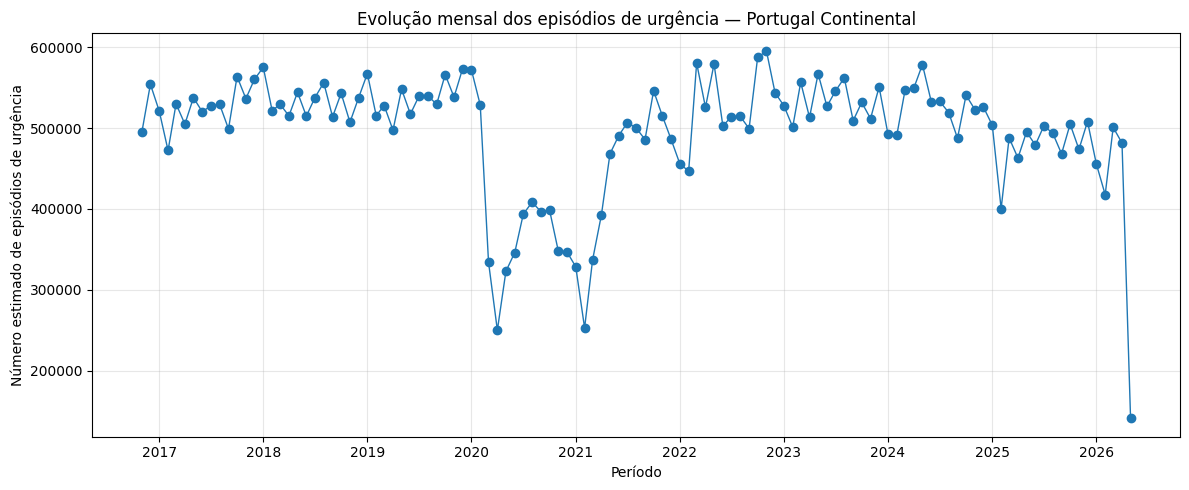

In [88]:
# Define a pasta onde os gráficos serão guardados
FIGURES_DIR = Path("../reports/figures")

# Cria a pasta, caso ainda não exista
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cria a figura e o eixo do gráfico
fig, ax = plt.subplots(figsize=(12, 5))

# Cria a linha temporal com o total mensal de episódios de urgência
ax.plot(
    df_nacional_mensal["periodo_mes"],
    df_nacional_mensal["episodios_urgencia_total"],
    marker="o",
    linewidth=1
)

# Define título e nomes dos eixos
ax.set_title("Evolução mensal dos episódios de urgência — Portugal Continental")
ax.set_xlabel("Período")
ax.set_ylabel("Número estimado de episódios de urgência")

# Adiciona grelha para facilitar a leitura
ax.grid(True, alpha=0.3)

# Ajusta o layout do gráfico
plt.tight_layout()

# Guarda o gráfico em formato PNG para usar no relatório e no GitHub
plt.savefig(
    FIGURES_DIR / "evolucao_mensal_episodios_urgencia_portugal_continental.png",
    dpi=300
)

# Mostra o gráfico no notebook
plt.show()

#### Resumo anual dos episódios de urgência

Após a análise mensal, foi criada uma síntese anual dos episódios de urgência em Portugal Continental.

Esta análise permite comparar anos, mas exige cuidado metodológico: o total anual não deve ser interpretado da mesma forma em anos completos, anos parciais ou anos com falhas de cobertura.

In [89]:
# Agrupa os dados nacionais por ano e calcula indicadores anuais dos episódios de urgência
df_nacional_anual = (
    df_nacional
    .groupby(["ano", "estado_ano"], as_index=False)
    .agg(
        episodios_urgencia_total=("episodios_urgencia", "sum"),
        episodios_urgencia_media_diaria=("episodios_urgencia", "mean"),
        episodios_urgencia_min_diario=("episodios_urgencia", "min"),
        episodios_urgencia_max_diario=("episodios_urgencia", "max"),
        dias_com_registo=("periodo", "count")
    )
)

# Ordena a tabela por ano
df_nacional_anual = df_nacional_anual.sort_values("ano")

# Mostra a síntese anual
df_nacional_anual

,ano,estado_ano,episodios_urgencia_total,episodios_urgencia_media_diaria,episodios_urgencia_min_diario,episodios_urgencia_max_diario,dias_com_registo
0,2016,parcial,1049139.0,17199.000000,12818.0,22550.0,61
1,2017,completo,6303240.0,17269.150685,13387.0,22787.0,365
2,2018,completo,6396197.0,17523.827397,13712.0,21782.0,365
3,2019,completo,6461275.0,17702.123288,14105.0,21909.0,365
4,2020,completo,4645501.0,12692.625683,6368.0,21772.0,366
5,2021,completo,5310261.0,14548.660274,7352.0,20374.0,365
6,2022,completo,6345815.0,17385.794521,11897.0,23386.0,365
7,2023,completo,6405266.0,17548.673973,13190.0,21979.0,365
8,2024,completo,6321201.0,17271.040984,12619.0,21240.0,366
9,2025,completo_com_falhas,5780820.0,16013.351801,10634.0,19429.0,361


In [90]:
# Filtra apenas os anos completos para permitir uma comparação anual mais justa
df_nacional_anual_completo = df_nacional_anual[
    df_nacional_anual["estado_ano"] == "completo"
].copy()

# Mostra apenas os anos completos
df_nacional_anual_completo

,ano,estado_ano,episodios_urgencia_total,episodios_urgencia_media_diaria,episodios_urgencia_min_diario,episodios_urgencia_max_diario,dias_com_registo
1,2017,completo,6303240.0,17269.150685,13387.0,22787.0,365
2,2018,completo,6396197.0,17523.827397,13712.0,21782.0,365
3,2019,completo,6461275.0,17702.123288,14105.0,21909.0,365
4,2020,completo,4645501.0,12692.625683,6368.0,21772.0,366
5,2021,completo,5310261.0,14548.660274,7352.0,20374.0,365
6,2022,completo,6345815.0,17385.794521,11897.0,23386.0,365
7,2023,completo,6405266.0,17548.673973,13190.0,21979.0,365
8,2024,completo,6321201.0,17271.040984,12619.0,21240.0,366


In [91]:
# Identifica o ano completo com maior média diária de episódios de urgência
ano_maior_media = df_nacional_anual_completo.loc[
    df_nacional_anual_completo["episodios_urgencia_media_diaria"].idxmax()
]

# Identifica o ano completo com menor média diária de episódios de urgência
ano_menor_media = df_nacional_anual_completo.loc[
    df_nacional_anual_completo["episodios_urgencia_media_diaria"].idxmin()
]

print("Ano completo com maior média diária:")
print(ano_maior_media[["ano", "episodios_urgencia_media_diaria"]])

print("\nAno completo com menor média diária:")
print(ano_menor_media[["ano", "episodios_urgencia_media_diaria"]])

Ano completo com maior média diária:
ano                                        2019
episodios_urgencia_media_diaria    17702.123288
Name: 3, dtype: object

Ano completo com menor média diária:
ano                                        2020
episodios_urgencia_media_diaria    12692.625683
Name: 4, dtype: object


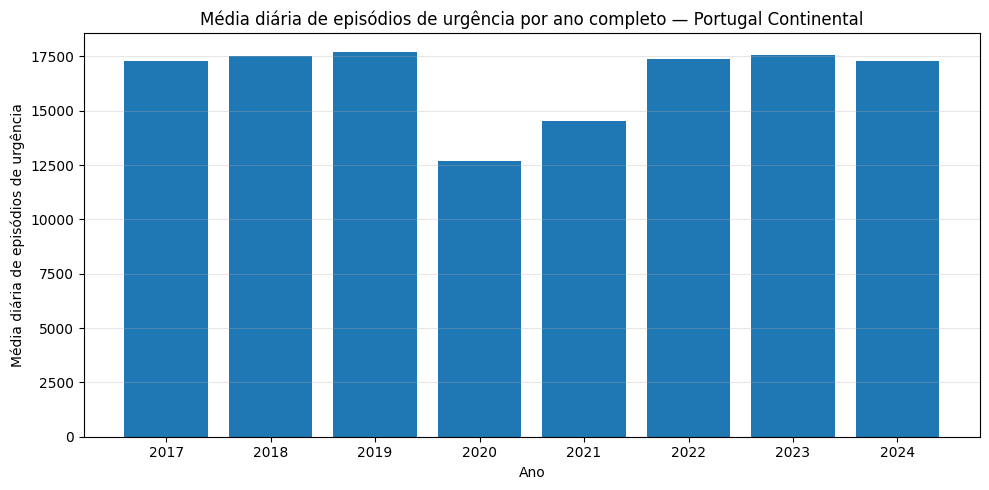

In [92]:
# Cria a figura e o eixo do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Cria um gráfico de barras com a média diária anual dos episódios de urgência
ax.bar(
    df_nacional_anual_completo["ano"].astype(str),
    df_nacional_anual_completo["episodios_urgencia_media_diaria"]
)

# Define título e nomes dos eixos
ax.set_title("Média diária de episódios de urgência por ano completo — Portugal Continental")
ax.set_xlabel("Ano")
ax.set_ylabel("Média diária de episódios de urgência")

# Adiciona grelha horizontal para facilitar a leitura
ax.grid(axis="y", alpha=0.3)

# Ajusta o layout do gráfico
plt.tight_layout()

# Guarda o gráfico em formato PNG para usar no relatório e no GitHub
plt.savefig(
    FIGURES_DIR / "media_diaria_episodios_urgencia_anos_completos_portugal_continental.png",
    dpi=300
)

# Mostra o gráfico no notebook
plt.show()

A comparação anual foi limitada aos anos classificados como completos, de forma a evitar interpretações enviesadas por anos parciais ou com falhas pontuais de cobertura.

A média diária de episódios de urgência foi usada como indicador principal de comparação anual, por ser mais adequada do que o total anual quando existem diferenças no número de dias disponíveis.

Esta análise permite identificar anos com maior ou menor procura média diária nas urgências hospitalares de Portugal Continental. No entanto, os resultados devem ser interpretados como descrição da atividade observada, não como avaliação de desempenho dos serviços ou como explicação causal das variações.

In [93]:
# Calcula a variação percentual entre o ano com maior e menor média diária
variacao_2019_2020 = (
    (
        ano_menor_media["episodios_urgencia_media_diaria"]
        - ano_maior_media["episodios_urgencia_media_diaria"]
    )
    / ano_maior_media["episodios_urgencia_media_diaria"]
) * 100

# Mostra a variação percentual arredondada
round(variacao_2019_2020, 1)

np.float64(-28.3)

#### Interpretação dos resultados anuais

Considerando apenas os anos classificados como completos, o ano com maior média diária de episódios de urgência foi 2019, com cerca de 17 702 episódios por dia em Portugal Continental.

O ano com menor média diária foi 2020, com cerca de 12 693 episódios por dia. Esta quebra representa uma redução aproximada de 28,3% face a 2019.

Esta diferença sugere uma alteração marcada na procura registada nos serviços de urgência em 2020. No entanto, nesta fase a análise mantém-se descritiva: o dataset permite identificar a quebra, mas não permite, por si só, explicar causalmente essa variação.

A comparação por média diária é mais adequada do que a comparação por total anual, porque reduz o enviesamento provocado por anos com diferentes níveis de cobertura temporal.

### 6.3 Evolução temporal nacional do tempo médio de espera

Nesta etapa é analisada a evolução do tempo médio de espera, em minutos, entre a triagem e a primeira observação médica em Portugal Continental.

Este indicador aproxima-se mais diretamente da ideia de pressão assistencial do que o número de episódios isoladamente, porque permite observar se a procura registada se acompanha de maior ou menor demora no acesso à primeira observação médica.

A análise é feita numa base mensal, calculando a média mensal dos valores diários publicados no dataset.

In [94]:
# Verifica os primeiros meses disponíveis para o tempo médio de espera
df_nacional_mensal[
    ["periodo_mes", "ano", "mes", "estado_ano", "tempo_medio_espera_media", "dias_com_tempo_espera"]
].head()

,periodo_mes,ano,mes,estado_ano,tempo_medio_espera_media,dias_com_tempo_espera
0,2016-11-01,2016,11,parcial,54.694792,30
1,2016-12-01,2016,12,parcial,69.238225,31
2,2017-01-01,2017,1,completo,56.183480,31
3,2017-02-01,2017,2,completo,48.213850,28
4,2017-03-01,2017,3,completo,47.699132,31


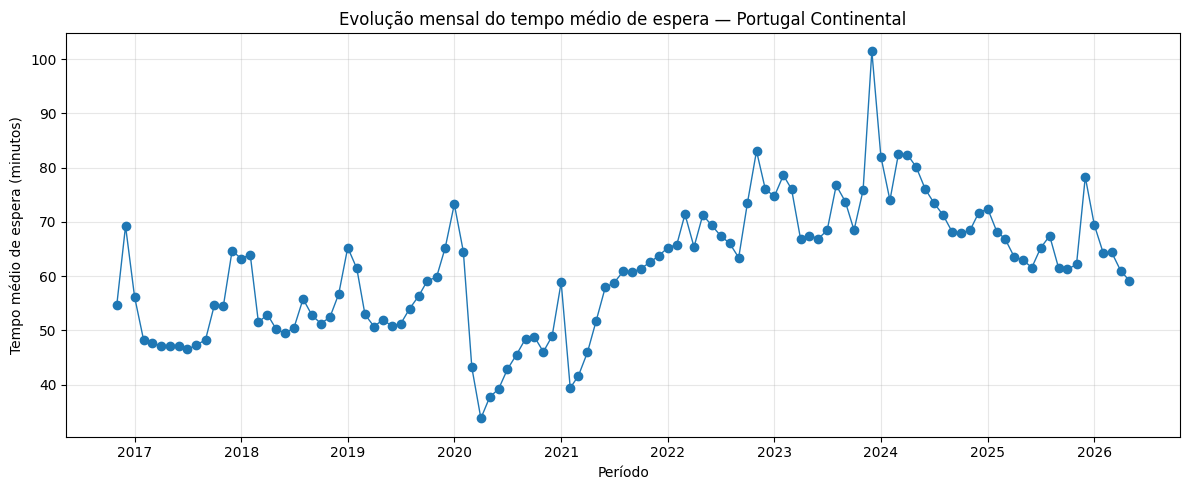

In [98]:
# Cria a figura e o eixo do gráfico
fig, ax = plt.subplots(figsize=(12, 5))

# Cria a linha temporal com a média mensal do tempo médio de espera
ax.plot(
    df_nacional_mensal["periodo_mes"],
    df_nacional_mensal["tempo_medio_espera_media"],
    marker="o",
    linewidth=1
)

# Define título e nomes dos eixos
ax.set_title("Evolução mensal do tempo médio de espera — Portugal Continental")
ax.set_xlabel("Período")
ax.set_ylabel("Tempo médio de espera (minutos)")

# Adiciona grelha para facilitar a leitura
ax.grid(True, alpha=0.3)

# Ajusta o layout do gráfico
plt.tight_layout()

# Guarda o gráfico em formato PNG para usar no relatório e no GitHub
plt.savefig(
    FIGURES_DIR / "evolucao_mensal_tempo_medio_espera_portugal_continental.png",
    dpi=300
)

# Mostra o gráfico no notebook
plt.show()

In [99]:
# Identifica o mês com maior tempo médio de espera
mes_maior_espera = df_nacional_mensal.loc[
    df_nacional_mensal["tempo_medio_espera_media"].idxmax()
]

# Identifica o mês com menor tempo médio de espera
mes_menor_espera = df_nacional_mensal.loc[
    df_nacional_mensal["tempo_medio_espera_media"].idxmin()
]

print("Mês com maior tempo médio de espera:")
print(mes_maior_espera[["periodo_mes", "tempo_medio_espera_media", "estado_ano"]])

print("\nMês com menor tempo médio de espera:")
print(mes_menor_espera[["periodo_mes", "tempo_medio_espera_media", "estado_ano"]])

Mês com maior tempo médio de espera:
periodo_mes                 2023-12-01 00:00:00
tempo_medio_espera_media             101.450568
estado_ano                             completo
Name: 85, dtype: object

Mês com menor tempo médio de espera:
periodo_mes                 2020-04-01 00:00:00
tempo_medio_espera_media              33.812828
estado_ano                             completo
Name: 41, dtype: object


A evolução mensal do tempo médio de espera permite observar a variação temporal deste indicador em Portugal Continental.

Ao contrário do número de episódios de urgência, este indicador não representa volume de atividade, mas sim uma medida temporal associada ao percurso do utente entre a triagem e a primeira observação médica.

A análise mensal permite reduzir o ruído diário e identificar períodos em que os tempos médios de espera se afastam do padrão habitual da série. No entanto, estes resultados devem ser interpretados de forma descritiva. O dataset permite identificar variações no indicador, mas não permite, por si só, explicar as causas dessas alterações.

In [100]:
# Calcula a diferença absoluta entre o maior e o menor tempo médio de espera mensal
diferenca_espera_minutos = (
    mes_maior_espera["tempo_medio_espera_media"]
    - mes_menor_espera["tempo_medio_espera_media"]
)

# Calcula a diferença percentual face ao menor valor observado
diferenca_espera_percentual = (
    diferenca_espera_minutos
    / mes_menor_espera["tempo_medio_espera_media"]
) * 100

print("Diferença absoluta entre extremos mensais:")
print(round(diferenca_espera_minutos, 1), "minutos")

print("\nDiferença percentual face ao menor valor:")
print(round(diferenca_espera_percentual, 1), "%")

Diferença absoluta entre extremos mensais:
67.6 minutos

Diferença percentual face ao menor valor:
200.0 %


#### Interpretação dos extremos mensais do tempo médio de espera

Na série mensal nacional, o maior tempo médio de espera foi observado em dezembro de 2023, com cerca de 101,5 minutos.

O menor tempo médio de espera foi observado em abril de 2020, com cerca de 33,8 minutos.

Estes valores mostram uma variação expressiva do indicador ao longo do período analisado. No entanto, esta análise identifica apenas os meses extremos da série e não permite, por si só, explicar as causas das diferenças observadas.

A ocorrência do valor mínimo em abril de 2020 deve ser interpretada com cautela, dado tratar-se de um período temporalmente atípico. A análise permanece descritiva e não assume causalidade.

#### Resumo anual do tempo médio de espera

Após a análise mensal, foi criada uma síntese anual do tempo médio de espera em Portugal Continental.

Tal como na análise dos episódios de urgência, a comparação anual deve ser limitada aos anos completos para evitar interpretações enviesadas por anos parciais ou por falhas de cobertura.

In [101]:
# Agrupa os dados nacionais por ano e calcula indicadores anuais do tempo médio de espera
df_espera_anual = (
    df_nacional
    .groupby(["ano", "estado_ano"], as_index=False)
    .agg(
        tempo_medio_espera_media=("tempo_medio_espera", "mean"),
        tempo_medio_espera_min=("tempo_medio_espera", "min"),
        tempo_medio_espera_max=("tempo_medio_espera", "max"),
        dias_com_registo=("periodo", "count"),
        dias_com_tempo_espera=("tempo_medio_espera", "count")
    )
)

# Ordena a tabela por ano
df_espera_anual = df_espera_anual.sort_values("ano")

# Mostra a síntese anual do tempo médio de espera
df_espera_anual

,ano,estado_ano,tempo_medio_espera_media,tempo_medio_espera_min,tempo_medio_espera_max,dias_com_registo,dias_com_tempo_espera
0,2016,parcial,62.085717,39.88894,103.20090,61,61
1,2017,completo,50.836613,34.87885,97.96091,365,365
2,2018,completo,54.191373,36.50892,98.47736,365,365
3,2019,completo,56.572740,36.95177,89.30264,365,365
4,2020,completo,47.683238,24.54189,85.63314,366,366
5,2021,completo,55.429878,28.20257,81.76393,365,365
6,2022,completo,69.865645,44.55950,99.94090,365,365
7,2023,completo,74.616253,49.92040,161.40000,365,365
8,2024,completo,74.853825,53.35740,147.25700,366,366
9,2025,completo_com_falhas,65.961196,41.87280,110.94200,361,361


In [102]:
# Filtra apenas os anos completos para permitir uma comparação anual mais justa
df_espera_anual_completo = df_espera_anual[
    df_espera_anual["estado_ano"] == "completo"
].copy()

# Mostra apenas os anos completos
df_espera_anual_completo

,ano,estado_ano,tempo_medio_espera_media,tempo_medio_espera_min,tempo_medio_espera_max,dias_com_registo,dias_com_tempo_espera
1,2017,completo,50.836613,34.87885,97.96091,365,365
2,2018,completo,54.191373,36.50892,98.47736,365,365
3,2019,completo,56.572740,36.95177,89.30264,365,365
4,2020,completo,47.683238,24.54189,85.63314,366,366
5,2021,completo,55.429878,28.20257,81.76393,365,365
6,2022,completo,69.865645,44.55950,99.94090,365,365
7,2023,completo,74.616253,49.92040,161.40000,365,365
8,2024,completo,74.853825,53.35740,147.25700,366,366


In [103]:
# Identifica o ano completo com maior tempo médio de espera
ano_maior_espera = df_espera_anual_completo.loc[
    df_espera_anual_completo["tempo_medio_espera_media"].idxmax()
]

# Identifica o ano completo com menor tempo médio de espera
ano_menor_espera = df_espera_anual_completo.loc[
    df_espera_anual_completo["tempo_medio_espera_media"].idxmin()
]

print("Ano completo com maior tempo médio de espera:")
print(ano_maior_espera[["ano", "tempo_medio_espera_media"]])

print("\nAno completo com menor tempo médio de espera:")
print(ano_menor_espera[["ano", "tempo_medio_espera_media"]])

Ano completo com maior tempo médio de espera:
ano                              2024
tempo_medio_espera_media    74.853825
Name: 8, dtype: object

Ano completo com menor tempo médio de espera:
ano                              2020
tempo_medio_espera_media    47.683238
Name: 4, dtype: object


In [105]:
# Calcula a diferença absoluta entre o maior e o menor tempo médio de espera anual
diferenca_espera_anual_minutos = (
    ano_maior_espera["tempo_medio_espera_media"]
    - ano_menor_espera["tempo_medio_espera_media"]
)

# Calcula a diferença percentual face ao menor valor anual observado
diferenca_espera_anual_percentual = (
    diferenca_espera_anual_minutos
    / ano_menor_espera["tempo_medio_espera_media"]
) * 100

print("Diferença absoluta entre extremos anuais:")
print(round(diferenca_espera_anual_minutos, 1), "minutos")

print("\nDiferença percentual face ao menor valor anual:")
print(round(diferenca_espera_anual_percentual, 1), "%")

Diferença absoluta entre extremos anuais:
27.2 minutos

Diferença percentual face ao menor valor anual:
57.0 %


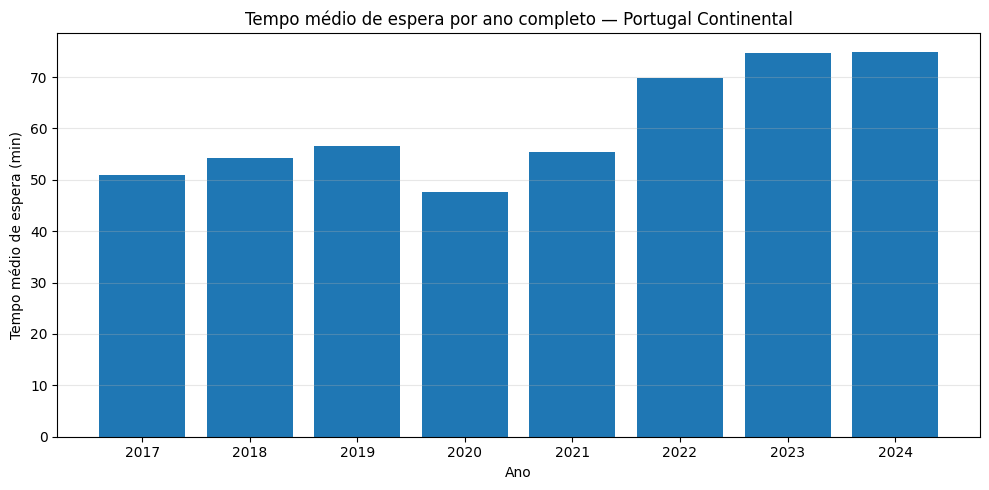

In [104]:
# Cria a figura e o eixo do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Cria um gráfico de barras com o tempo médio de espera por ano completo
ax.bar(
    df_espera_anual_completo["ano"].astype(str),
    df_espera_anual_completo["tempo_medio_espera_media"]
)

# Define título e nomes dos eixos
ax.set_title("Tempo médio de espera por ano completo — Portugal Continental")
ax.set_xlabel("Ano")
ax.set_ylabel("Tempo médio de espera (min)")

# Adiciona grelha horizontal para facilitar a leitura
ax.grid(axis="y", alpha=0.3)

# Ajusta o layout do gráfico
plt.tight_layout()

# Guarda o gráfico em formato PNG para usar no relatório e no GitHub
plt.savefig(
    FIGURES_DIR / "tempo_medio_espera_anos_completos_portugal_continental.png",
    dpi=300
)

# Mostra o gráfico no notebook
plt.show()

#### Interpretação anual do tempo médio de espera

Considerando apenas os anos classificados como completos, o maior tempo médio de espera anual foi observado em 2024, com cerca de 74,9 minutos.

O menor valor anual foi observado em 2020, com cerca de 47,7 minutos. A diferença entre estes dois anos corresponde a aproximadamente 27,2 minutos, ou cerca de 57,0% face ao menor valor anual observado.

Esta variação sugere que o tempo médio de espera apresenta diferenças relevantes ao longo do período analisado. Em conjunto com a análise mensal, estes resultados indicam que o tempo médio de espera é um indicador importante para monitorizar sinais de pressão assistencial nas urgências hospitalares.

Ainda assim, a análise permanece descritiva. Os dados permitem identificar períodos com valores mais elevados ou mais baixos, mas não permitem, por si só, explicar as causas dessas variações nem avaliar diretamente o desempenho dos serviços.